OBJECTIVE 1

Profile & QA the data



In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df=pd.read_csv("Listings.csv", encoding='latin1')
df.head()

/tmp/ipython-input-2748073901.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("Listings.csv", encoding='latin1')


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2.0,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2.0,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2.0,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2.0,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2.0,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36670 entries, 0 to 36669
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   listing_id                   36670 non-null  int64  
 1   name                         36604 non-null  object 
 2   host_id                      36670 non-null  int64  
 3   host_since                   36670 non-null  object 
 4   host_location                36554 non-null  object 
 5   host_response_time           10494 non-null  object 
 6   host_response_rate           10494 non-null  float64
 7   host_acceptance_rate         13596 non-null  float64
 8   host_is_superhost            36669 non-null  object 
 9   host_total_listings_count    36669 non-null  float64
 10  host_has_profile_pic         36669 non-null  object 
 11  host_identity_verified       36669 non-null  object 
 12  neighbourhood                36669 non-null  object 
 13  district        

changing the data type to DATE type

In [26]:
df['host_since']=pd.to_datetime(df['host_since'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18192 entries, 0 to 36633
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     18192 non-null  datetime64[ns]
 1   neighbourhood  18192 non-null  object        
 2   city           18192 non-null  object        
 3   accommodates   18192 non-null  float64       
 4   price          18192 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 852.8+ KB


In [11]:
df = df[['host_since', 'neighbourhood', 'city', 'accommodates', 'price']]
df

,host_since,neighbourhood,city,accommodates,price
0,2011-12-03,Buttes-Montmartre,Paris,2.0,53.0
1,2013-11-29,Buttes-Montmartre,Paris,2.0,120.0
2,2014-07-31,Elysee,Paris,2.0,89.0
3,2013-12-17,Vaugirard,Paris,2.0,58.0
4,2014-12-14,Passy,Paris,2.0,60.0
...,...,...,...,...,...
36665,2019-08-23,Sathon,Bangkok,4.0,1500.0
36666,2014-10-30,Yau Tsim Mong,Hong Kong,4.0,743.0
36667,2015-05-17,Miguel Hidalgo,Mexico City,2.0,987.0
36668,2015-06-27,Ward 84,Cape Town,4.0,2045.0


In [12]:
n_col=df.select_dtypes(include=["int64",'float64']).columns
name_col=df.select_dtypes(include=["object"]).columns


In [13]:
df[n_col]=df[n_col].fillna(df[n_col].median())
df[n_col]
df[n_col].isnull().sum()

,0
accommodates,0
price,0


In [14]:
df[name_col]=df[name_col].fillna(df[name_col].mode())
df[name_col]

,neighbourhood,city
0,Buttes-Montmartre,Paris
1,Buttes-Montmartre,Paris
2,Elysee,Paris
3,Vaugirard,Paris
4,Passy,Paris
...,...,...
36665,Sathon,Bangkok
36666,Yau Tsim Mong,Hong Kong
36667,Miguel Hidalgo,Mexico City
36668,Ward 84,Cape Town


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36670 entries, 0 to 36669
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     36669 non-null  datetime64[ns]
 1   neighbourhood  36669 non-null  object        
 2   city           36669 non-null  object        
 3   accommodates   36670 non-null  float64       
 4   price          36670 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 1.4+ MB


In [16]:
df=df[df['city']=='Paris']
df['city'].unique()
df

,host_since,neighbourhood,city,accommodates,price
0,2011-12-03,Buttes-Montmartre,Paris,2.0,53.0
1,2013-11-29,Buttes-Montmartre,Paris,2.0,120.0
2,2014-07-31,Elysee,Paris,2.0,89.0
3,2013-12-17,Vaugirard,Paris,2.0,58.0
4,2014-12-14,Passy,Paris,2.0,60.0
...,...,...,...,...,...
36629,2014-09-22,Vaugirard,Paris,4.0,210.0
36630,2013-07-22,Temple,Paris,4.0,210.0
36631,2018-07-01,Batignolles-Monceau,Paris,4.0,300.0
36632,2016-05-04,Buttes-Chaumont,Paris,6.0,70.0


In [17]:
df.describe()

,host_since,accommodates,price
count,18192,18192.000000,18192.000000
mean,2015-09-02 08:59:41.002638848,3.032432,98.802661
min,2009-02-14 00:00:00,1.000000,8.000000
25%,2014-04-09 00:00:00,2.000000,60.000000
50%,2015-05-31 00:00:00,2.000000,80.000000
75%,2016-08-27 06:00:00,4.000000,105.000000
max,2021-02-03 00:00:00,14.000000,12000.000000
std,NaN,1.341089,153.559400


In [18]:
df[n_col].min()


,0
accommodates,1.0
price,8.0


In [19]:
df[n_col].max()

,0
accommodates,14.0
price,12000.0


In [20]:
df[n_col].mean()

,0
accommodates,3.032432
price,98.802661


In [21]:
df.isnull().sum()

,0
host_since,0
neighbourhood,0
city,0
accommodates,0
price,0


In [22]:
df=df.dropna()
df.isnull().sum()

,0
host_since,0
neighbourhood,0
city,0
accommodates,0
price,0


In [23]:
df

,host_since,neighbourhood,city,accommodates,price
0,2011-12-03,Buttes-Montmartre,Paris,2.0,53.0
1,2013-11-29,Buttes-Montmartre,Paris,2.0,120.0
2,2014-07-31,Elysee,Paris,2.0,89.0
3,2013-12-17,Vaugirard,Paris,2.0,58.0
4,2014-12-14,Passy,Paris,2.0,60.0
...,...,...,...,...,...
36629,2014-09-22,Vaugirard,Paris,4.0,210.0
36630,2013-07-22,Temple,Paris,4.0,210.0
36631,2018-07-01,Batignolles-Monceau,Paris,4.0,300.0
36632,2016-05-04,Buttes-Chaumont,Paris,6.0,70.0


In [25]:
df['neighbourhood'].unique()

array(['Buttes-Montmartre', 'Elysee', 'Vaugirard', 'Passy', 'Temple',
       'Popincourt', 'Buttes-Chaumont', 'Opera', 'Gobelins',
       'Hotel-de-Ville', 'Pantheon', 'Enclos-St-Laurent',
       'Batignolles-Monceau', 'Luxembourg', 'Reuilly', 'Menilmontant',
       'Observatoire', 'Palais-Bourbon', 'Bourse', 'Louvre'], dtype=object)

by the end of objective 1:

succesfully created the accureate needs to the data {import,casting ,filtered,...}.

 OBJECTIVE 2

Prepare the data for visualization

In [33]:
paris_listings_neighbourhood=df.groupby('neighbourhood')['price'].mean().sort_values(ascending=True)
paris_listings_neighbourhood

,price
neighbourhood,
Menilmontant,73.589113
Buttes-Chaumont,74.222121
Reuilly,82.352417
Popincourt,83.108718
Observatoire,86.962006
Buttes-Montmartre,89.961363
Batignolles-Monceau,93.178495
Enclos-St-Laurent,93.379926
Vaugirard,97.590551


In [103]:
maxNH = paris_listings_neighbourhood.index[-1]
maxNH
#save the most neighbourhood price

'Elysee'

In [35]:
paris_listings_accomodations=df.groupby('accommodates')['price'].mean().sort_values(ascending=True)
paris_listings_accomodations


,price
accommodates,
1.0,56.293801
2.0,76.590009
3.0,87.972061
4.0,112.253731
5.0,160.062865
6.0,184.945368
7.0,204.621951
12.0,272.000000
9.0,300.600000


In [51]:
df['DATE']=  df['host_since'].dt.year
#change the type to year only

In [50]:
paris_listings_over_time = df.groupby('DATE').agg(
    avg_price=('price', 'mean'),
    num_new_hosts=('host_since', 'count'))
paris_listings_over_time

,avg_price,num_new_hosts
DATE,,
2009,105.166667,6
2010,105.561404,57
2011,96.717314,283
2012,96.101779,1012
2013,95.072811,2376
2014,94.430987,3608
2015,97.049952,4184
2016,93.405073,2523
2017,97.153846,1183


by the end of objective 2:

succesfully created the three paris_listings with the accureate needs.

 OBJECTIVE 3

Visualize the data and summarize findings

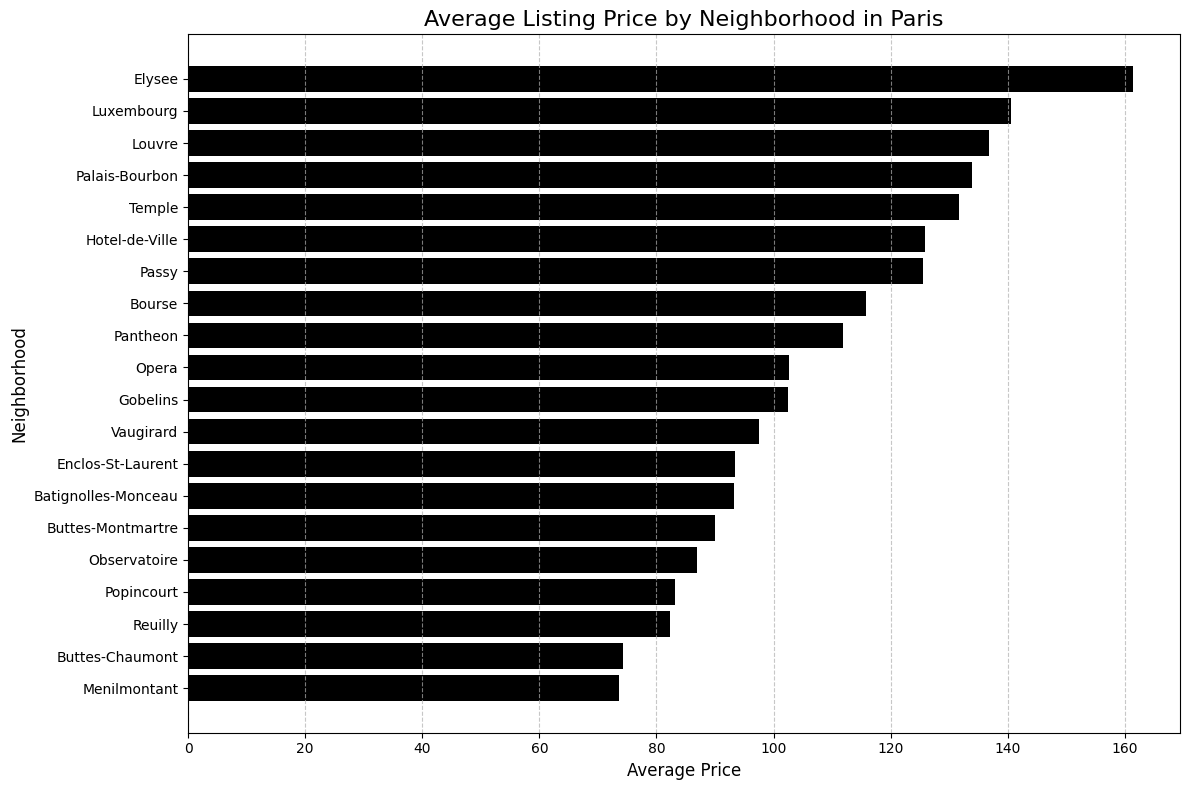

In [59]:
plt.figure(figsize=(12, 8))
plt.barh(paris_listings_neighbourhood.index, paris_listings_neighbourhood.values, color='black')
plt.title('Average Listing Price by Neighborhood in Paris', fontsize=16)
plt.xlabel('Average Price', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

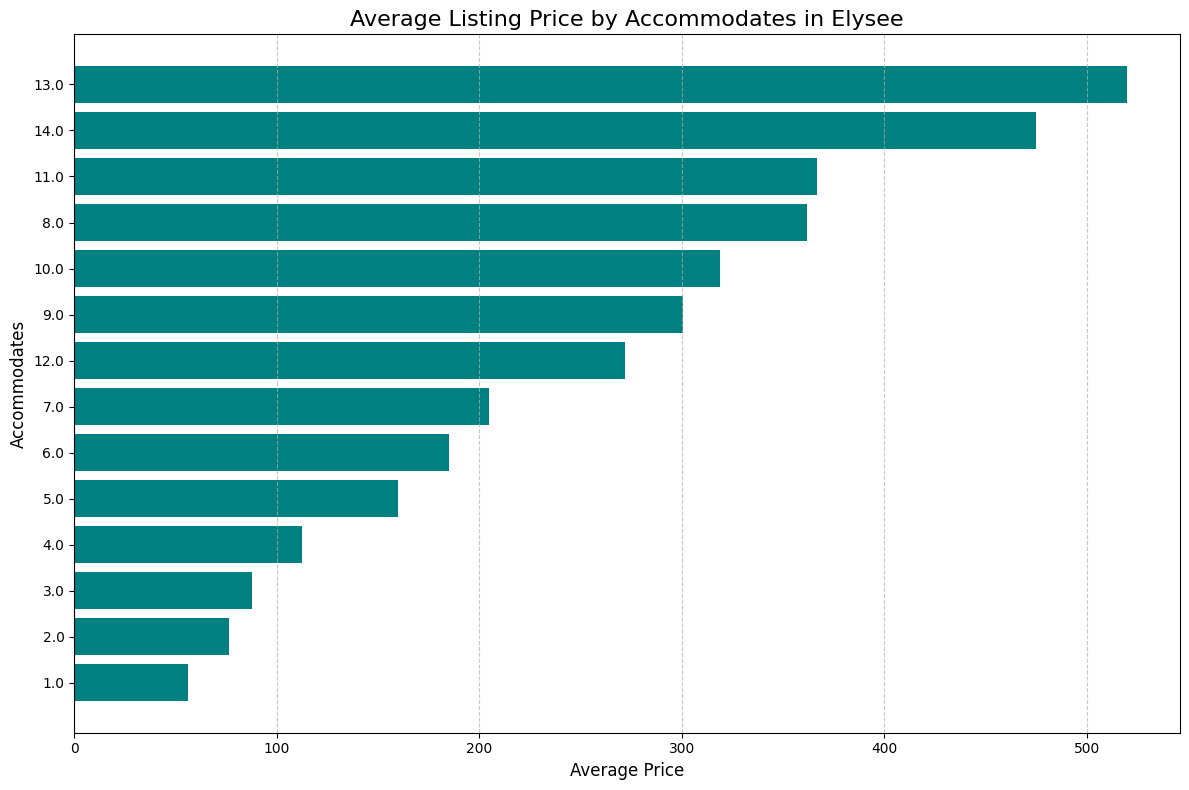

In [108]:
avg_maxNH=df.groupby('accommodates')['price'].mean().sort_values()
plt.figure(figsize=(12, 8))
plt.barh(avg_maxNH.index.astype(str), avg_maxNH.values, color='teal')
plt.title(f'Average Listing Price by Accommodates in {maxNH}', fontsize=16)
plt.xlabel('Average Price', fontsize=12)
plt.ylabel('Accommodates', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

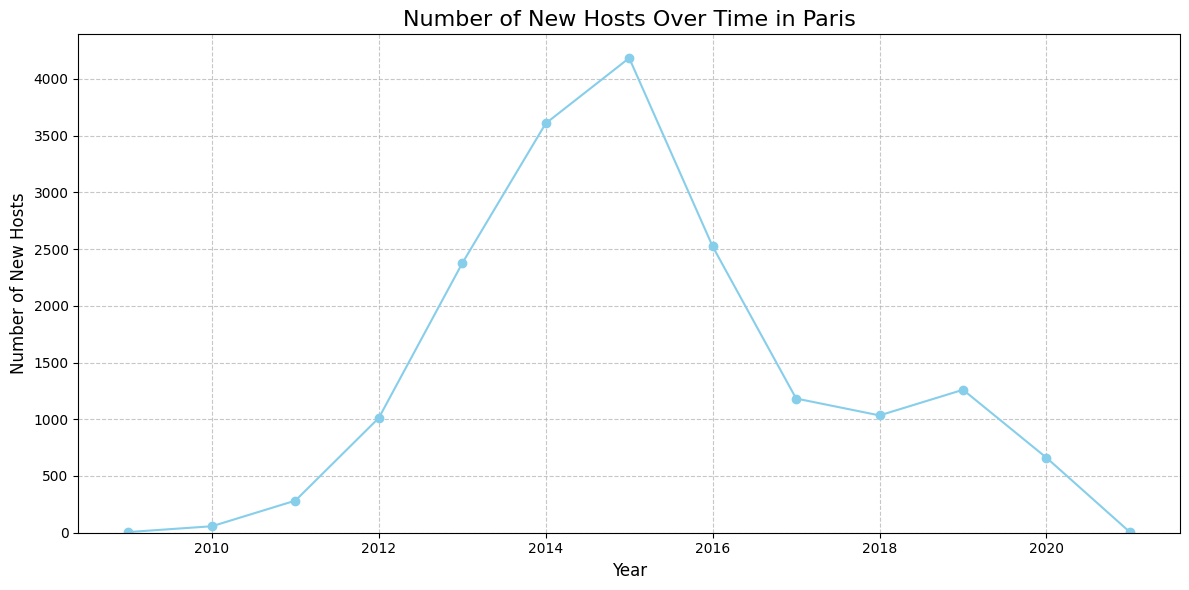

In [109]:
plt.figure(figsize=(12, 6))
plt.plot(paris_listings_over_time.index, paris_listings_over_time['num_new_hosts'], marker='o', color='skyblue')
plt.title('Number of New Hosts Over Time in Paris', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of New Hosts', fontsize=12)
plt.ylim(bottom=0) # Set y-axis limit to 0
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

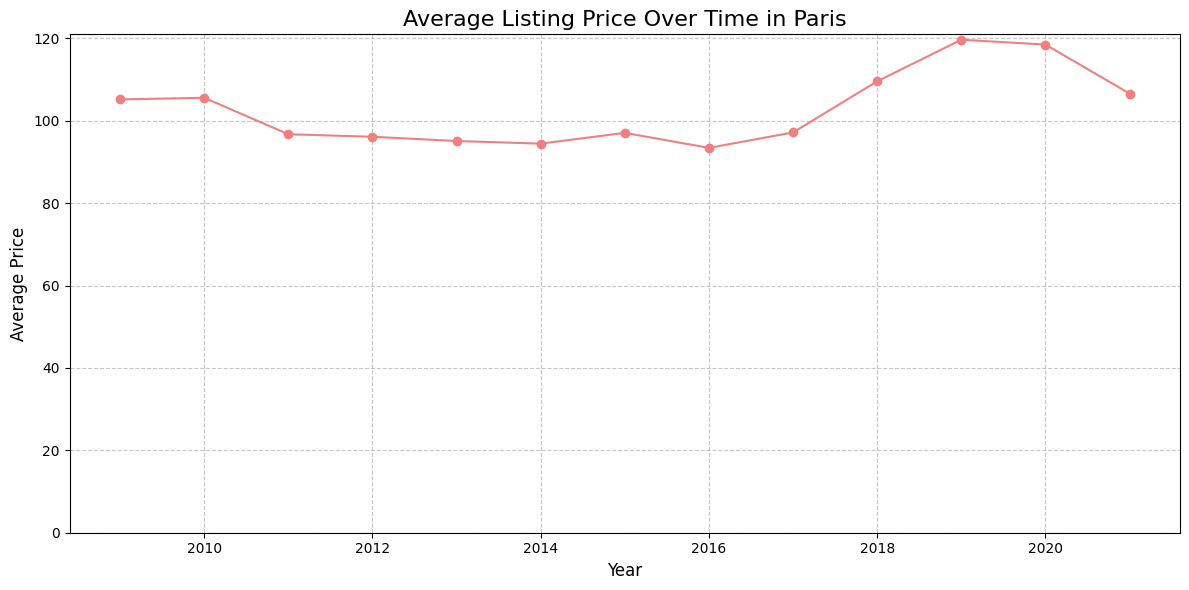

In [110]:
plt.figure(figsize=(12, 6))
plt.plot(paris_listings_over_time.index, paris_listings_over_time['avg_price'], marker='o', color='lightcoral')
plt.title('Average Listing Price Over Time in Paris', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.ylim(bottom=0) # Set y-axis limit to 0
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

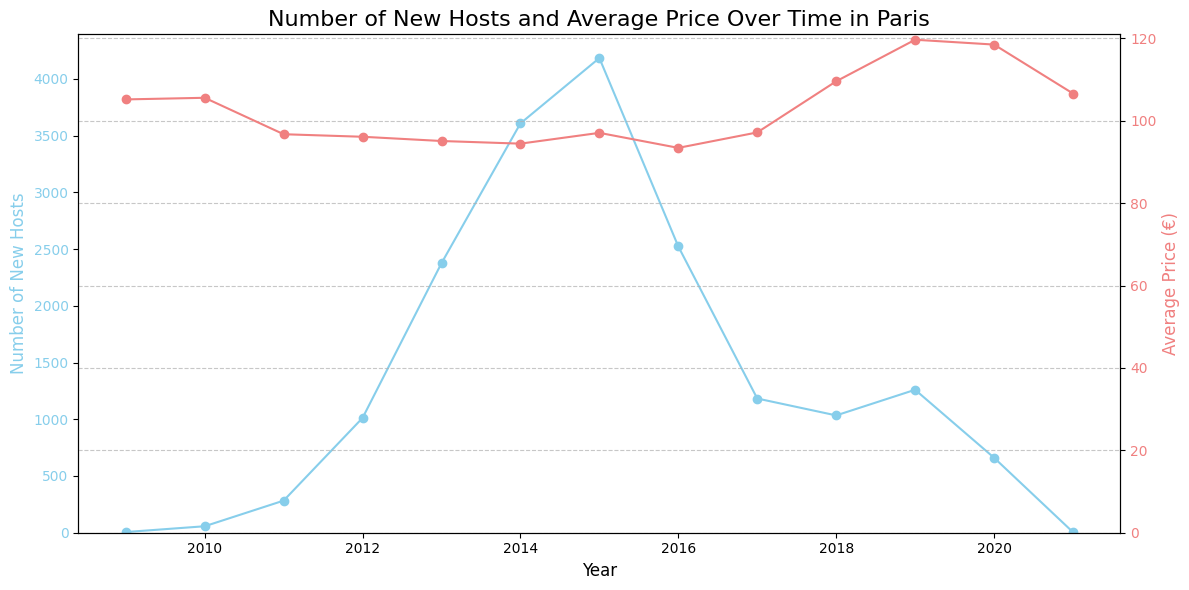

In [111]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'skyblue'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of New Hosts', color=color, fontsize=12)
ax1.plot(paris_listings_over_time.index, paris_listings_over_time['num_new_hosts'], marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(bottom=0)


ax2 = ax1.twinx()
color = 'lightcoral'
ax2.set_ylabel('Average Price', color=color, fontsize=12)
ax2.plot(paris_listings_over_time.index, paris_listings_over_time['avg_price'], marker='o', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(bottom=0)



plt.title('Number of New Hosts and Average Price Over Time in Paris', fontsize=16)
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#dual axis line chart show both new hosts and average price over time

by the end of objective 3 :

all visualization plots were done.

The number of new hosts saw a significant reach the top and drop after 2015.

---



Which neighborhood in Paris has the highest average AirBnB listing price?

**Elysee**







